In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torchvision
import numpy as np

In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the entire dataset
dataset = datasets.ImageFolder(root='./images', transform=transform)

In [3]:
dataset.classes

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [4]:
# Split the dataset into train and test sets
train_size = int(0.8 * len(dataset))  # 80% for training
test_size = len(dataset) - train_size  # 20% for testing
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

len(train_dataset), len(test_dataset)

(16510, 4128)

In [5]:
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
for i, (images, labels) in enumerate(train_loader):
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 128, 128])
torch.Size([32])


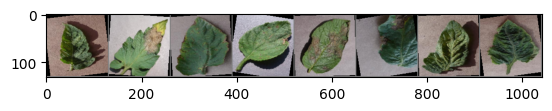

In [7]:
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# show images
imshow(torchvision.utils.make_grid(images[:8]))

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            
            nn.Conv2d(3, 32, kernel_size=(3,3), padding="same"), # output (32, 128, 128)
            nn.ReLU(), 
            nn.MaxPool2d(stride=(2,2), kernel_size=(2,2)), # output (32, 64, 64)
            
            nn.Conv2d(32, 64, kernel_size=(3,3), padding="same"), # output (64, 64, 64)
            nn.ReLU(), 
            nn.MaxPool2d(stride=(2,2), kernel_size=(2,2)),  # output (64, 32, 32)
            
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 256), 
            nn.ReLU(),
            nn.Linear(256, 128), 
            nn.ReLU(),            
            nn.Linear(128, num_classes) 
        )
    
    def forward(self, x):
        return self.network(x)

In [13]:
# Training loop
def train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=5):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

In [23]:
# Initialize model, loss function, and optimizer
num_classes = len(dataset.classes)
model = CNN(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=10)

Epoch [1/10], Loss: 0.9206
Epoch [2/10], Loss: 0.4117
Epoch [3/10], Loss: 0.3006
Epoch [4/10], Loss: 0.2115
Epoch [5/10], Loss: 0.1688
Epoch [6/10], Loss: 0.1569
Epoch [7/10], Loss: 0.1388
Epoch [8/10], Loss: 0.1178
Epoch [9/10], Loss: 0.1047
Epoch [10/10], Loss: 0.0959


In [24]:
def test_model(model, test_loader):
    # Evaluation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")
    
test_model(model, test_loader)    

Test Accuracy: 92.61%


In [12]:
def test_model(model, test_loader):
    # Evaluation loop
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

### Transfer Learning with Resnet

In [15]:
from torchvision import models

# Load pre-trained ResNet18 model
model = models.resnet18(weights='DEFAULT')

# Replace the fully connected layer
model.fc = nn.Linear(model.fc.in_features, len(dataset.classes))

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_model(model, optimizer, criterion, train_loader, test_loader, num_epochs=5)
test_model(model, test_loader)

Epoch [1/5], Loss: 0.4718
Epoch [2/5], Loss: 0.2060
Epoch [3/5], Loss: 0.1594
Epoch [4/5], Loss: 0.1405
Epoch [5/5], Loss: 0.1192
Test Accuracy: 94.36%
